# 🌳 Understanding Decision Trees: A Beginner's Guide 🌳

Welcome to this interactive guide on Decision Trees\! In this notebook, we'll explore one of the most intuitive and powerful machine learning algorithms.

**Learning Objectives:**

  * Understand what a Decision Tree is and how it makes decisions.
  * Learn key concepts like nodes, branches, leaves, and splitting criteria.
  * See how to implement a Decision Tree for classification using Python's `scikit-learn`.
  * Visualize a trained Decision Tree.
  * Understand basic hyperparameters and the concept of overfitting.

**We will cover:**
1.  **Introduction to Decision Trees**: What they are, how they work conceptually.
2.  **Key Concepts**: Nodes, branches, leaves, root, splitting criteria (Gini Impurity, Entropy), information gain.
3.  **How Decision Trees Learn**: The recursive partitioning process.
4.  **Pros and Cons**: Advantages and disadvantages.
5.  **Implementation in Python (Scikit-learn)**:
      * Loading a dataset (e.g., Iris or a simple custom dataset).
      * Data preparation (if necessary).
      * Training a `DecisionTreeClassifier`.
      * Visualizing the tree.
      * Making predictions.
      * Evaluating the model.
6.  **Hyperparameters**: Brief explanation of important ones (`max_depth`, `min_samples_leaf`, `criterion`).
7.  **Overfitting**: How it happens and basic mitigation (e.g., pruning, although `max_depth` is the most direct for a beginner).
8.  **Regression Trees**: Briefly mention their existence.
9.  **Further Learning/Next Steps**.

Let's get started\!

-----



## 1\. What is a Decision Tree? 🤔

Imagine you're trying to decide what to wear based on the weather. You might follow a thought process like this:

  * **Is it raining?**
      * If **Yes**: Wear a raincoat.
      * If **No**:
          * **Is it cold?**
              * If **Yes**: Wear a warm jacket.
              * If **No**: Wear a light jacket.

This sequential decision-making process, based on conditions, is exactly what a Decision Tree does\!

**Definition:** A Decision Tree is a supervised machine learning algorithm that can be used for both **classification** (predicting categories) and **regression** (predicting numerical values) tasks. It works by recursively partitioning the data based on features, creating a tree-like structure of decisions.

### Components of a Decision Tree:

  * **Root Node:** The topmost node, representing the entire dataset. It's the starting point of the decision process.
  * **Internal Node (Decision Node):** A node that represents a test on a feature (e.g., "Is it raining?"). It has two or more branches.
  * **Branch (Edge):** Represents the outcome of the test (e.g., "Yes" or "No"). It connects nodes.
  * **Leaf Node (Terminal Node):** A node that does not split further. It represents the final decision or prediction (e.g., "Wear a raincoat").

**Visual Analogy:**
Think of a flowchart. Each box is a node, and arrows are branches leading to the next decision or a final answer.

-----


![Image](https://images.datacamp.com/image/upload/v1677504957/decision_tree_for_heart_attack_prevention_2140bd762d.png)


## 2\. How Do Decision Trees Learn? 📚 (Splitting Criteria)

The core idea behind building a Decision Tree is to find the "best" way to split the data at each node. "Best" means that the split should create child nodes that are as **pure** as possible.

**What is Purity?**
A node is "pure" if all the data points in that node belong to the same class (for classification). If a node contains a mix of classes, it's "impure."

Decision Trees use various metrics to measure impurity and decide on the best split. The two most common are:

### a) Gini Impurity

  * **Concept:** Measures how often a randomly chosen element from the set would be incorrectly classified if it were randomly labeled according to the distribution of labels in the subset.
  * **Interpretation:** A Gini Impurity of 0 means perfect purity (all elements belong to the same class). A Gini Impurity of 0.5 (for a binary classification) means maximum impurity (classes are equally distributed).
  * **Formula (for a binary classification):**
    
   The formula for Gini Impurity is:

  $$
  Gini = 1 - \sum_{i=1}^{k} p_i^2
  $$

    Where:
    * $k$ is the number of classes.
    * $p_i$ is the probability of an item belonging to class $i$.

### b) Entropy

  * **Concept:** Measures the disorder or randomness in a set of data.
  * **Interpretation:** An Entropy of 0 means perfect purity. Higher entropy means more disorder.
  * **Formula (for a binary classification):**
    
    $Entropy = -p\_1 \\log\_2(p\_1) - p\_2 \\log\_2(p\_2) - ... - p\_k \\log\_2(p\_k)$


#### 🔍 **Information Gain**

**Information Gain** measures how much **uncertainty (entropy)** is reduced after a dataset is split on a feature.

It tells us **how useful a feature is** in classifying the target variable.

---

### 🧠 **Formula:**

$$
\text{Information Gain} = \text{Entropy (Parent)} - \sum \text{(Weighted Entropy of Children)}
$$

---

### 📌 **Use in Decision Trees:**

* Used by algorithms like **ID3** and **C4.5**.
* At each node, the feature with the **highest Information Gain** is selected to split the data.
* Helps build a tree that **best separates** the classes step by step.

---

### 📊 **Intuition:**

Higher Information Gain = **Better feature for splitting**

Let me know if you’d like this explained with an example or visualization!



-----

Types of Decision Tree Algorithm and their Criterion


| Criterion            | Used In   | Based On           | Purpose                                          |
| -------------------- | --------- | ------------------ | ------------------------------------------------ |
| **Gini Impurity**    | CART      | Probability        | Measures impurity directly                       |
| **Entropy**          | ID3, C4.5 | Information theory | Used to compute Information Gain                 |
| **Information Gain** | ID3       | Entropy            | Difference in entropy before and after the split |


 ### Purity for Regression

Let's talk about how Decision Trees work for **Regression** tasks.
While the goal is still to create pure nodes, the definition of "purity" is different for regression because we are predicting a continuous numerical value, not a category.

For regression, the "purity" of a node is measured by how similar the predicted values are within that node. The most common metrics for measuring impurity (or rather, homogeneity) in regression trees are:

### **Variance Reduction (or Mean Squared Error Reduction)**

*   **Concept:** This is the standard metric used in scikit-learn's `DecisionTreeRegressor`. It measures how much the variance of the target variable is reduced by splitting the data at a node.
*   **Interpretation:** A node is considered "pure" if all the data points within that node have similar target values, resulting in low variance. The best split is one that minimizes the variance in the resulting child nodes.
*   **How it works:**
    *   Calculate the impurity (variance) of the parent node.
    *   For each potential split, calculate the weighted average of the impurity (variance) of the resulting child nodes.
    *   The split that achieves the greatest reduction in impurity (variance) is chosen.

Let's formalize the concept using Mean Squared Error (MSE), which is directly related to variance. The goal is to minimize the MSE within each node.

For a given node $m$, containing a set of training instances $R_m$, the predicted value for all instances in this node is typically the mean of the target values:

$$
\bar{y}_m = \frac{1}{|R_m|} \sum_{x_i \in R_m} y_i
$$

The impurity (MSE) of node $m$ is then calculated as:

$$
MSE_m = \frac{1}{|R_m|} \sum_{x_i \in R_m} (y_i - \bar{y}_m)^2
$$

When considering a split that divides the instances in node $m$ into two child nodes, $R_{m, \text{left}}$ and $R_{m, \text{right}}$, the quality of the split is often evaluated by minimizing the weighted average MSE of the child nodes:

$$
\text{Cost of Split} = \frac{|R_{m, \text{left}}|}{|R_m|} MSE_{m, \text{left}} + \frac{|R_{m, \text{right}}|}{|R_m|} MSE_{m, \text{right}}
$$

The algorithm searches for the feature and the split point that minimizes this cost (or equivalently, maximizes the reduction in MSE compared to the parent node's MSE). The split point in a continuous feature is typically chosen as the midpoint between sorted unique values of that feature in the node's data.

*   **Purity Formula (based on MSE):**

    For a node $m$ with a set of data points $R_m$ and their corresponding target values $y_i$:

    $$
    \text{Purity (Homogeneity)} \propto \frac{1}{\frac{1}{|R_m|} \sum_{x_i \in R_m} (y_i - \bar{y}_m)^2}
    $$

    *A lower MSE value indicates higher purity (more homogeneity).*

Essentially, the splitting criterion for regression trees aims to create child nodes where the target values are as close as possible to each other. The prediction made at a leaf node in a regression tree is usually the average of the target values of all training instances that fall into that leaf node.


## 3\. Building a Decision Tree in Python (Scikit-learn) 🐍

Let's get hands-on and build a Decision Tree classifier using `scikit-learn`. We'll use the famous Iris dataset, which is perfect for classification tasks.

First, let's install necessary libraries (if running locally, Colab has most pre-installed).


-----


In [ ]:
# Install graphviz for visualization if you haven't already
# !pip install graphviz

# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import graphviz # Used for rendering the tree visualization

### 3.1. Load and Prepare Data

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())
print("\nTarget Names:", iris.target_names)
print("\nFeature Names:", iris.feature_names)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Features (X) head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y) head:
0    0
1    0
2    0
3    0
4    0
dtype: int64

Target Names: ['setosa' 'versicolor' 'virginica']

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Training set size: 105 samples
Testing set size: 45 samples


In [ ]:
# prompt: Print target names and their values
print(iris.target_names)
y.unique()

['setosa' 'versicolor' 'virginica']


array([0, 1, 2])

### 3.2. Train the Decision Tree Classifier

We'll create an instance of `DecisionTreeClassifier` and then `fit` it to our training data.

In [ ]:
# Create a Decision Tree Classifier
# max_depth: Limits the depth of the tree to prevent overfitting (more on this later!)
# random_state: Ensures reproducibility of the results
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


### 3.3. Visualize the Decision Tree

Visualizing the tree helps us understand how it makes decisions. We'll use `export_graphviz` and `graphviz`.

Decision Tree visualization saved as 'iris_decision_tree.png'.


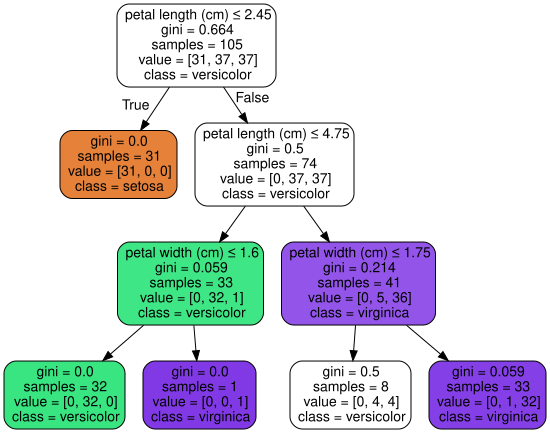

In [ ]:
# Export the tree to a DOT format
dot_data = export_graphviz(
    dt_classifier,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,      # Color nodes to indicate majority class
    rounded=True,     # Round corners of nodes
    special_characters=True
)

# Render the DOT graph
graph = graphviz.Source(dot_data)
graph.render("iris_decision_tree", format="png", view=False) # Saves to a file
print("Decision Tree visualization saved as 'iris_decision_tree.png'.")

# Display the graph within the Colab notebook
graph

**Understanding the Visualization:**

  * **Nodes:** Each box is a node.
  * **Condition:** The top line in a non-leaf node (`petal width (cm) <= 0.8`): This is the decision rule. If the condition is true, follow the left branch; otherwise, follow the right branch.
  * **`gini`:** The Gini impurity of the samples in that node.
  * **`samples`:** The number of training samples that reached this node.
  * **`value`:** The distribution of classes in that node. For example, `[35, 36, 34]` means 35 samples of class 0, 36 of class 1, and 34 of class 2.
  * **`class`:** The majority class in that node. This is the predicted class if this node were a leaf.
  * **Coloring:** Nodes are colored based on the majority class, with darker shades indicating higher purity.

### 3.4. Make Predictions and Evaluate the Model

Now that our tree is trained, let's see how well it performs on unseen data (our test set).

In [ ]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



An accuracy of 1.0 (or very close to it) is excellent\! This means our Decision Tree made correct predictions for all or almost all samples in the test set.

-----

## 4\. Hyperparameters: Controlling Tree Growth ⚙️

Decision Trees have various parameters that you can tune to control their learning process. These are called **hyperparameters**. Tuning them helps in optimizing model performance and preventing overfitting.

Common hyperparameters for `DecisionTreeClassifier`:

  * **`criterion`**: The function to measure the quality of a split.
      * `"gini"` (for Gini impurity, default)
      * `"entropy"` (for information gain using entropy)
  * **`max_depth`**: The maximum depth of the tree. If `None`, nodes are expanded until all leaves are pure or until all leaves contain less than `min_samples_split` samples.
      * **Crucial for preventing overfitting\!**
  * **`min_samples_split`**: The minimum number of samples required to split an internal node.
  * **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node. Any split that would result in a leaf containing fewer than this number of samples is disallowed.
  * **`max_features`**: The number of features to consider when looking for the best split.


### Experimenting with `max_depth`

Let's see what happens if we don't limit `max_depth` (or set it very high).

Accuracy (unlimited depth): 1.0000


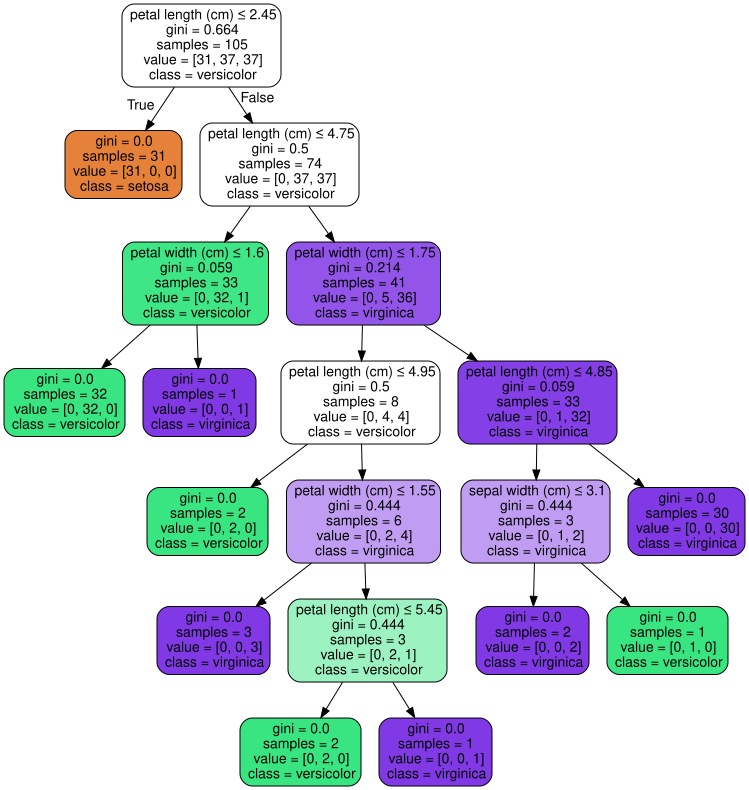

In [ ]:
# Create a Decision Tree Classifier with no max_depth limit
dt_unlimited = DecisionTreeClassifier(random_state=42)

# Train the model
dt_unlimited.fit(X_train, y_train)

# Make predictions
y_pred_unlimited = dt_unlimited.predict(X_test)

# Evaluate
accuracy_unlimited = accuracy_score(y_test, y_pred_unlimited)
print(f"Accuracy (unlimited depth): {accuracy_unlimited:.4f}")

# You can visualize this tree too, but it might be very large and complex!
dot_data_unlimited = export_graphviz(dt_unlimited, out_file=None,
                                      feature_names=iris.feature_names,
                                      class_names=iris.target_names,
                                      filled=True, rounded=True, special_characters=True)
graph_unlimited = graphviz.Source(dot_data_unlimited)
graph_unlimited

#### Experimenting with `max_depth` = 1



In [ ]:
# Create a Decision Tree Classifier
# max_depth: Limits the depth of the tree to prevent overfitting (more on this later!)
# random_state: Ensures reproducibility of the results
dt_classifier_controlled = DecisionTreeClassifier(max_depth=1, random_state=42)

# Train the model
dt_classifier_controlled.fit(X_train, y_train)

# Make predictions
y_pred_controlled = dt_classifier_controlled.predict(X_test)

# Evaluate
accuracy_controlled = accuracy_score(y_test, y_pred_controlled)
print(f"Accuracy (unlimited depth): {accuracy_controlled:.4f}")



Accuracy (unlimited depth): 0.7111


Even though the accuracy might seem similar or even slightly better, an unconstrained tree is more prone to **overfitting**.

-----

## 5\. Overfitting in Decision Trees 🍂

**Overfitting** occurs when a model learns the training data too well, including its noise and outliers. While it performs great on the training data, its performance on new, unseen data suffers significantly.

**Why do Decision Trees Overfit?**
Decision Trees, especially without depth limits, can grow very deep and create complex rules that perfectly fit the training data. Imagine a tree that has a separate leaf node for almost every single training example. This tree has memorized the training data rather than learning general patterns.

**How to Mitigate Overfitting:**

  * **Pruning:** This involves removing branches from the tree that have low predictive power. In `scikit-learn`, this is primarily done by setting hyperparameters like:
      * `max_depth`: Limits how deep the tree can go. (Most common and effective for beginners).
      * `min_samples_leaf`: Ensures each leaf node has a minimum number of samples, preventing creation of leaves for single outliers.
      * `min_impurity_decrease`: Requires a minimum reduction in impurity for a split to occur.
  * **Cross-validation:** A technique to evaluate model performance robustly on multiple subsets of the data, helping to detect overfitting.
  * **Ensemble Methods:** Techniques like Random Forests and Gradient Boosting combine multiple decision trees to reduce overfitting and improve robustness. (More advanced topic\!)

-----



## 6\. Decision Trees for Regression 📈 (Briefly)

While we focused on classification, Decision Trees can also be used for **regression** tasks. The primary difference is how the "purity" is measured and what the leaf nodes predict:

  * **Splitting Criteria:** Instead of Gini or Entropy, regression trees typically use metrics like **Mean Squared Error (MSE)** or **Mean Absolute Error (MAE)** to decide on splits. The goal is to minimize the variance of the target variable within each node.
  * **Leaf Prediction:** Each leaf node in a regression tree predicts the **average** (or median) value of the target variable for all the training samples that fall into that leaf.

-----



## 7\. Pros and Cons of Decision Trees ✅❌

**Advantages:**

  * **Easy to Understand and Interpret:** The tree structure is very intuitive, and rules can be easily visualized and explained.
  * **Handles Both Numerical and Categorical Data:** Doesn't require extensive preprocessing like scaling.
  * **No Assumption about Data Distribution:** Non-parametric method.
  * **Can Handle Multi-Output Problems.**

**Disadvantages:**

  * **Prone to Overfitting:** Especially with deep trees, they can easily overfit noisy data.
  * **Instability:** Small variations in the data can lead to a completely different tree structure.
  * **Bias towards Dominant Classes:** If there's an imbalance in class distribution, the tree might be biased towards the majority class.
  * **Local Optima:** The greedy approach of choosing the best split at each step doesn't guarantee the globally optimal tree.

-----



## 8\. Further Learning & Next Steps 🚀

Decision Trees are a foundational algorithm. Here are some directions for further exploration:

  * **Ensemble Methods:** Dive into **Random Forests** and **Gradient Boosting (XGBoost, LightGBM)**. These are powerful algorithms that use multiple decision trees to overcome the limitations of a single tree, especially overfitting.
  * **Hyperparameter Tuning:** Learn about techniques like Grid Search and Randomized Search to systematically find the best hyperparameters for your models.
  * **Cost-Complexity Pruning (CCP):** A more sophisticated pruning technique available in `scikit-learn` (using `ccp_alpha`).
  * **Feature Importance:** Understand how Decision Trees can provide insights into which features are most important for making predictions.

-----

This concludes our introduction to Decision Trees\! You now have a solid understanding of how they work, how to implement them, and key considerations for their use. Keep experimenting and building\!

## 9.Resources:




1.   [Decision Tree](https://www.geeksforgeeks.org/machine-learning/decision-tree/)
2.   [What is a Decision Tree?](https://www.ibm.com/think/topics/decision-trees)
3.   [Decision Tree Algorithm](https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/)
4.   [Decision Tree Classfication Python](https://www.datacamp.com/tutorial/decision-tree-classification-python)



## 10.Example of Decision Tree Regressor

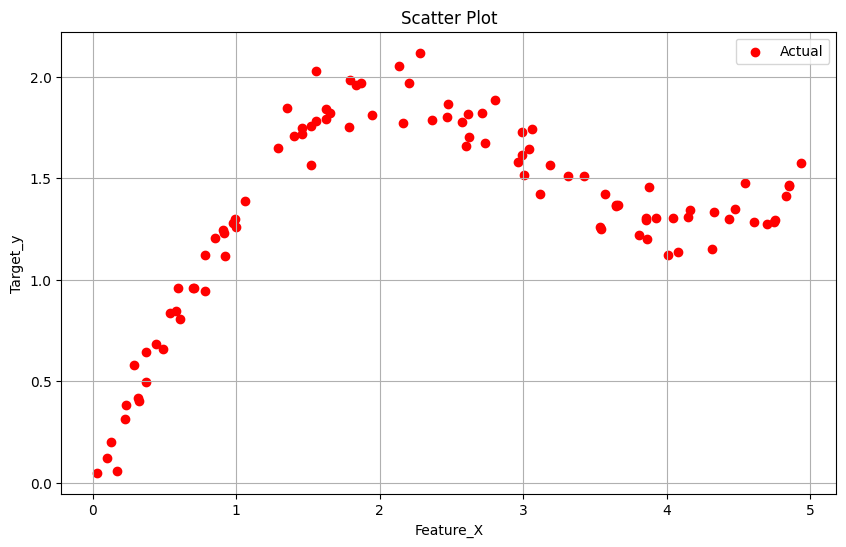


--- Decision Tree Regressor Example ---
Training set size (regression): 70 samples
Testing set size (regression): 30 samples

Decision Tree Regressor trained successfully!

Mean Squared Error (MSE): 0.0082
Regression Decision Tree visualization saved as 'regression_decision_tree.png'.


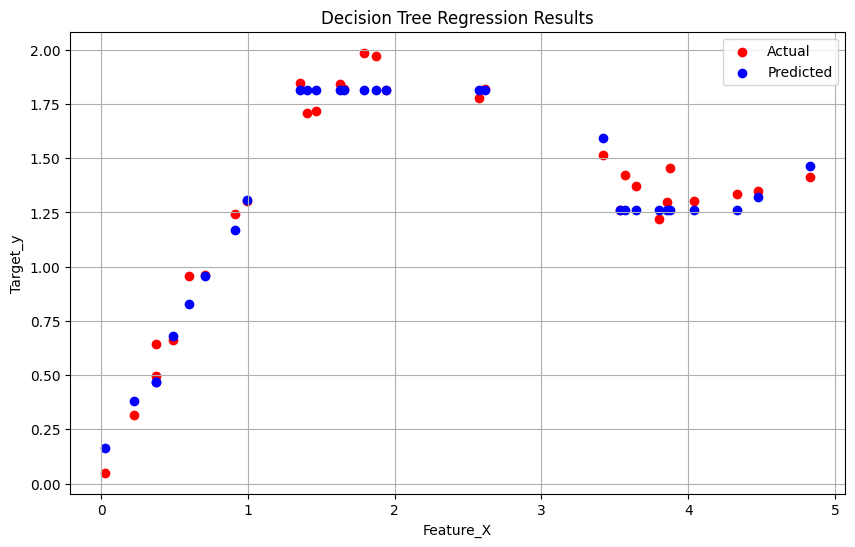

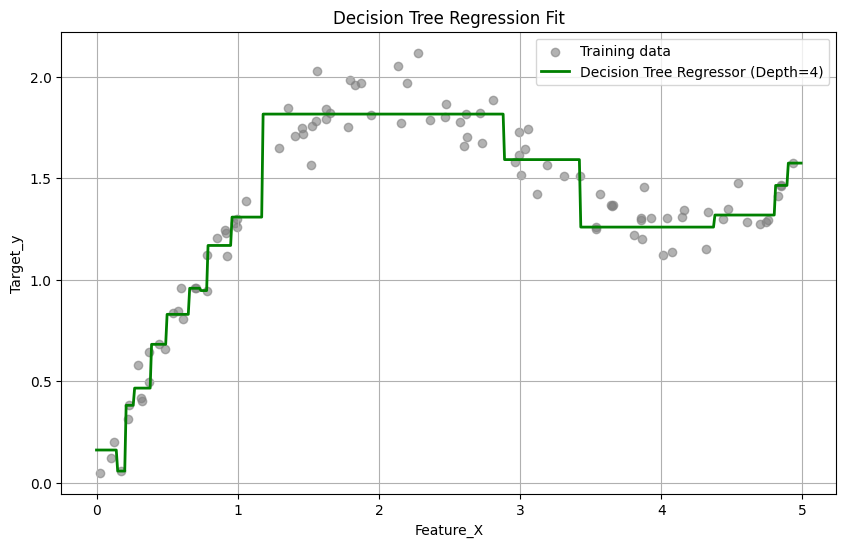

In [ ]:
# prompt: Create a example of decision tree regressor

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Generate some synthetic regression data
# We'll use a simple quadratic relationship with some noise
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(100, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, size=100) + X_reg.ravel() * 0.5

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, color='red', label='Actual')
plt.title('Scatter Plot')
plt.xlabel('Feature_X')
plt.ylabel('Target_y')
plt.legend()
plt.grid(True)
plt.show()

# Split regression data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print("\n--- Decision Tree Regressor Example ---")
print(f"Training set size (regression): {X_train_reg.shape[0]} samples")
print(f"Testing set size (regression): {X_test_reg.shape[0]} samples")

# Create a Decision Tree Regressor
# criterion='squared_error' (formerly 'mse') is the default and corresponds to minimizing MSE
# max_depth can be tuned to control complexity
dt_regressor = DecisionTreeRegressor(max_depth=4, random_state=42)

# Train the model
dt_regressor.fit(X_train_reg, y_train_reg)

print("\nDecision Tree Regressor trained successfully!")

# Make predictions on the test set
y_pred_reg = dt_regressor.predict(X_test_reg)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test_reg, y_pred_reg)
print(f"\nMean Squared Error (MSE): {mse:.4f}")

# --- Optional: Visualize the Regression Tree ---
# This can also be done using export_graphviz and graphviz
# Note: Feature names and class names are not applicable in the same way for regression trees
dot_data_reg = export_graphviz(
    dt_regressor,
    out_file=None,
    feature_names=['Feature_X'], # Give a placeholder name
    filled=True,
    rounded=True,
    special_characters=True,
    precision=2 # Control the number of decimals shown
)

graph_reg = graphviz.Source(dot_data_reg)
graph_reg.render("regression_decision_tree", format="png", view=False)
print("Regression Decision Tree visualization saved as 'regression_decision_tree.png'.")

# Display the graph within the Colab notebook
graph_reg

# --- Optional: Plot the regression results ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_test_reg, y_test_reg, color='red', label='Actual')
plt.scatter(X_test_reg, y_pred_reg, color='blue', label='Predicted')
plt.title('Decision Tree Regression Results')
plt.xlabel('Feature_X')
plt.ylabel('Target_y')
plt.legend()
plt.grid(True)
plt.show()

# Also plot the learned function on the training range
X_plot = np.arange(0, 5, 0.01)[:, np.newaxis]
y_plot_pred = dt_regressor.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, color='gray', label='Training data', alpha=0.6)
plt.plot(X_plot, y_plot_pred, color='green', label=f'Decision Tree Regressor (Depth={dt_regressor.max_depth})', linewidth=2)
plt.title('Decision Tree Regression Fit')
plt.xlabel('Feature_X')
plt.ylabel('Target_y')
plt.legend()
plt.grid(True)
plt.show()

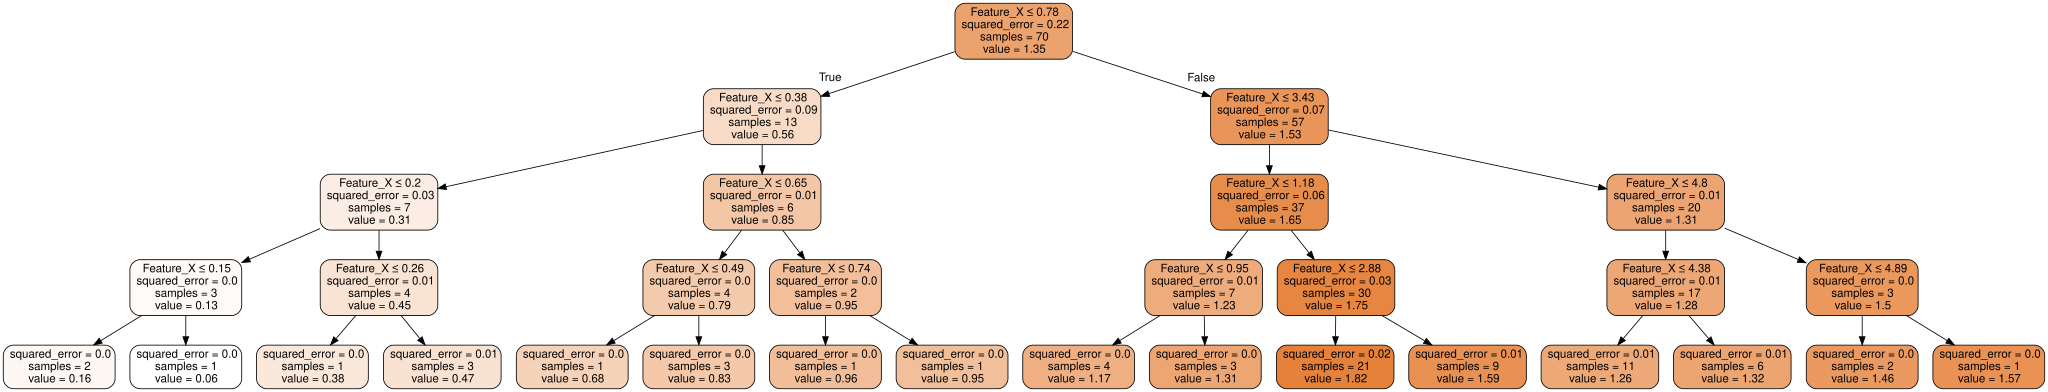

In [ ]:
# prompt: Display the regression decision tree plot

# Display the graph within the Colab notebook
graph_reg

## 11.Example Decision Tree Built using Gini Index

Let's walk step by step through how a **Decision Tree** works for a **classification** task using the **Gini Index**. We'll create a **simple example** using **3 features** and a **binary target (Yes/No)** and build **one level of the tree**, explaining the **math** at each step.

---

### 🎯 Problem Setup

Suppose you have the following dataset:

| ID | Feature A | Feature B | Feature C | Target |
| -- | --------- | --------- | --------- | ------ |
| 1  | High      | Yes       | 5         | Yes    |
| 2  | Medium    | No        | 7         | No     |
| 3  | Low       | No        | 8         | No     |
| 4  | High      | Yes       | 6         | Yes    |
| 5  | Medium    | No        | 9         | No     |
| 6  | Low       | Yes       | 4         | Yes    |

Let’s assume:

* **Feature A**: Categorical → `High`, `Medium`, `Low`
* **Feature B**: Binary → `Yes`, `No`
* **Feature C**: Numeric
* **Target**: Binary classification → `Yes` or `No`

We want to build the **first split** of a decision tree using the **Gini Index**.

---

### 🔢 Step 1: Gini Index Formula

The **Gini Impurity** for a node is calculated as:

$$
Gini(D) = 1 - \sum_{i=1}^{C} p_i^2
$$

Where:

* $D$ is the dataset at that node.
* $C$ is the number of classes.
* $p_i$ is the proportion of class $i$ in dataset $D$.

---

### 🔍 Step 2: Gini Index of the Root Node (before any split)

We have 6 examples:

* 3 are **Yes**
* 3 are **No**

$$
p_{\text{Yes}} = \frac{3}{6} = 0.5,\quad p_{\text{No}} = \frac{3}{6} = 0.5
$$

$$
Gini_{\text{root}} = 1 - (0.5)^2 - (0.5)^2 = 1 - 0.25 - 0.25 = 0.5
$$

---

### 🔍 Step 3: Evaluate Gini for Each Feature Split

---

#### 📌 Feature A: Categorical (High, Medium, Low)

We split into 3 groups:

* **High**: Rows 1, 4 → Target: Yes, Yes
* **Medium**: Rows 2, 5 → Target: No, No
* **Low**: Rows 3, 6 → Target: No, Yes

Now calculate Gini for each:

##### High:

$$
Gini = 1 - (1)^2 = 0
$$

##### Medium:

$$
Gini = 1 - (1)^2 = 0
$$

##### Low:

1 Yes, 1 No → $p_{\text{Yes}} = 0.5$

$$
Gini = 1 - (0.5)^2 - (0.5)^2 = 0.5
$$

Now compute the **weighted average Gini** for the split:

$$
Gini_{FeatureA} = \frac{2}{6}(0) + \frac{2}{6}(0) + \frac{2}{6}(0.5) = \frac{1}{6} \approx 0.167
$$

---

#### 📌 Feature B: Binary (Yes, No)

* **Yes**: Rows 1, 4, 6 → Targets: Yes, Yes, Yes → All Yes
* **No**: Rows 2, 3, 5 → Targets: No, No, No → All No

Both pure:

$$
Gini_{\text{Yes}} = Gini_{\text{No}} = 0
$$

$$
Gini_{FeatureB} = \frac{3}{6}(0) + \frac{3}{6}(0) = 0
$$

✅ **Best split so far!**

---

#### 📌 Feature C: Numeric

We need to sort the values and try all possible thresholds:
Feature C values: 4, 5, 6, 7, 8, 9

Possible thresholds: between (4,5), (5,6), (6,7), (7,8), (8,9) → pick midpoint

Let’s try **threshold = 6.5**

#### Left split (C ≤ 6.5): Rows 1, 4, 6 → Targets: Yes, Yes, Yes → Gini = 0

#### Right split (C > 6.5): Rows 2, 3, 5 → Targets: No, No, No → Gini = 0

So:

$$
Gini_{FeatureC@6.5} = \frac{3}{6}(0) + \frac{3}{6}(0) = 0
$$

So this split is also **perfect**!

---

### ✅ Step 4: Choosing the Best Split

We compare Gini scores:

| Feature          | Gini Index |
| ---------------- | ---------- |
| Feature A        | 0.167      |
| Feature B        | 0          |
| Feature C (≤6.5) | 0          |

So we can split on either **Feature B** or **Feature C (<= 6.5)**.

Both give perfect separation, but **decision trees typically prefer simpler splits** — splitting on a **binary feature** like **Feature B** is most interpretable.

---

### 🌳 Final Output: First Split of the Tree or Root of the Tree

```
If Feature B == Yes:
    Predict: Yes
Else:
    Predict: No
```

---

#### 🧠 Summary of Concepts:

| Concept           | Explanation                          |
| ----------------- | ------------------------------------ |
| Gini Index        | Measures impurity of a node          |
| Weighted Gini     | Average impurity after a split       |
| Best Split        | Feature with lowest post-split Gini  |
| Categorical Split | Grouped by category values           |
| Numeric Split     | Try thresholds between sorted values |

---


Now that **Feature B** has been selected as the **root node**, the dataset is split into two branches:

### 🌳 Root Node Split:

```
if Feature B == Yes:
    --> Left branch
else:
    --> Right branch
```

Let’s walk through how to choose the **next feature** at each branch, step by step using **Gini index** again.

---

## 📌 Re-split the data based on Feature B

From your original data:

| ID | Feature A | Feature B | Feature C | Target |
| -- | --------- | --------- | --------- | ------ |
| 1  | High      | Yes       | 5         | Yes    |
| 2  | Medium    | No        | 7         | No     |
| 3  | Low       | No        | 8         | No     |
| 4  | High      | Yes       | 6         | Yes    |
| 5  | Medium    | No        | 9         | No     |
| 6  | Low       | Yes       | 4         | Yes    |

### After splitting on **Feature B**:

#### 🔹 Left branch: **Feature B = Yes**

| ID | Feature A | Feature C | Target |
| -- | --------- | --------- | ------ |
| 1  | High      | 5         | Yes    |
| 4  | High      | 6         | Yes    |
| 6  | Low       | 4         | Yes    |

* All targets = Yes → **Pure node**
* 🎯 **Gini = 0 → No further split needed**

---

#### 🔸 Right branch: **Feature B = No**

| ID | Feature A | Feature C | Target |
| -- | --------- | --------- | ------ |
| 2  | Medium    | 7         | No     |
| 3  | Low       | 8         | No     |
| 5  | Medium    | 9         | No     |

* All targets = No → **Pure node**
* 🎯 **Gini = 0 → No further split needed**

---

### 🎉 Final Tree Structure

```
Root Node: Feature B
├── If Yes → Predict: Yes
└── If No  → Predict: No
```

---

### 🧠 Key Learning:

* After splitting on **Feature B**, both resulting nodes (left and right) are **pure**.
* So the **tree stops** growing — it's already done a perfect separation.
* No need to evaluate Feature A or Feature C at next levels because there’s **no impurity left** to reduce.

---

### But What If the Nodes Weren’t Pure?

If even one child node wasn't pure, then you’d:

1. Take that subset of data (say, the "No" side).
2. For the remaining features (Feature A and C), compute **Gini index for each**.
3. Pick the feature that results in the **lowest weighted Gini impurity** **after the split**.

You’d repeat this **recursively** until:

* All leaves are pure, or
* A stopping condition is met (e.g., `max_depth`, `min_samples_split`)

---


Now, let's simulate a case where **after splitting on Feature B**, the resulting nodes **are not pure**, so we have to compute the next-level split manually using the **Gini index**.

---

### 🧪 Modified Data (Impure Nodes)

Let's slightly tweak your original data to make one child node **impure**.

| ID | Feature A | Feature B | Feature C | Target                           |
| -- | --------- | --------- | --------- | -------------------------------- |
| 1  | High      | Yes       | 5         | Yes                              |
| 2  | Medium    | No        | 7         | No                               |
| 3  | Low       | No        | 8         | No                               |
| 4  | High      | Yes       | 6         | No     ⬅️ changed from Yes to No |
| 5  | Medium    | No        | 9         | No                               |
| 6  | Low       | Yes       | 4         | Yes                              |

---

#### 📍 Now we split on **Feature B** again

##### 🔹 Left branch: **Feature B = Yes**

| ID | Feature A | Feature C | Target |
| -- | --------- | --------- | ------ |
| 1  | High      | 5         | Yes    |
| 4  | High      | 6         | **No** |
| 6  | Low       | 4         | Yes    |

👉 Not pure: 2 Yes, 1 No

---

#### 🔸 Right branch: **Feature B = No**

| ID | Feature A | Feature C | Target |
| -- | --------- | --------- | ------ |
| 2  | Medium    | 7         | No     |
| 3  | Low       | 8         | No     |
| 5  | Medium    | 9         | No     |

✅ All No → Pure → Gini = 0 → No split needed

---

Now let’s focus on **Left Branch** and compute the best split between the **remaining features**:

* Feature A (categorical: High, Low)
* Feature C (numeric: 4, 5, 6)

---

### 🧮 Step-by-Step: Feature A Split

#### Values:

* **High**: IDs 1, 4 → Targets: Yes, No
* **Low**: ID 6 → Target: Yes

##### Group Gini:

* High → 1 Yes, 1 No → Gini = 0.5
* Low  → 1 Yes → Gini = 0

##### Weighted Gini:

$$
Gini = \frac{2}{3}(0.5) + \frac{1}{3}(0) = \frac{1}{3} \approx 0.333
$$

---

### 🧮 Step-by-Step: Feature C Split

Values: 4, 5, 6 → Try splitting at 4.5 and 5.5

---

#### Try threshold = 4.5

* **Left (≤4.5)**: ID 6 → Target: Yes → Gini = 0
* **Right (>4.5)**: IDs 1, 4 → Targets: Yes, No → Gini = 0.5

$$
Gini = \frac{1}{3}(0) + \frac{2}{3}(0.5) = \frac{1}{3} \approx 0.333
$$

---

#### Try threshold = 5.5

* **Left (≤5.5)**: IDs 1, 6 → Targets: Yes, Yes → Gini = 0
* **Right (>5.5)**: ID 4 → Target: No → Gini = 0

$$
Gini = \frac{2}{3}(0) + \frac{1}{3}(0) = 0 ✅ Best split
$$

---

### ✅ Choose Best Feature and Threshold

| Feature          | Gini After Split |
| ---------------- | ---------------- |
| Feature A        | 0.333            |
| Feature C (≤5.5) | **0.0** ✅        |

---

### 🌳 Updated Tree Structure

```
Root Node: Feature B
├── If No → Predict: No (pure)
└── If Yes:
    ├── If Feature C ≤ 5.5 → Predict: Yes
    └── Else → Predict: No
```

---

### 💡 Key Concepts Demonstrated

| Concept                   | Shown Here |
| ------------------------- | ---------- |
| Post-root splitting       | ✅          |
| Weighted Gini computation | ✅          |
| Categorical vs numeric    | ✅          |
| Recursive growth          | ✅          |

---

